# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [1]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [2]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("../data/output/events_combined.csv")

df.head()


,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,...,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour,source
0,2d5cf2bb-79a8-4a8a-b61f-087d446829b1,Guided Tour in the Historical Food Hall Österm...,https://bielstencompany.se/noje/privatvisning,https://images.unsplash.com/...,2026-05-03,NaN,onsale,Miscellaneous,Food & Drink,NaN,...,NaN,"Östermalmstorg 31, Stockholm, Sweden",59.335954,18.077689,Sunday,May,5,2026,NaN,visitstockholm
1,4f6d2b81-8fed-488f-901d-3e716c8c49ef,Postis!,https://www.postmuseum.se/utstallning/postis/,https://images.unsplash.com/...,2026-05-03,NaN,onsale,Arts & Theatre,Culture & Arts,Nature & Society,...,Stockholm,Lilla Nygatan 6,59.322253,18.148724,Sunday,May,5,2026,NaN,visitstockholm
2,7e90f24e-4fc4-4687-86ef-3c4ff0577141,Spring Gala – Opera & Choral Music,https://tikkio.com/events/62948?fbclid=IwY2xja...,https://images.unsplash.com/...,2026-05-03,NaN,onsale,Music,Jazz & Blues,Pop,...,Stockholm,Narvavägen 13-17,59.333999,18.091719,Sunday,May,5,2026,NaN,visitstockholm
3,e7c06dc1-80d7-484a-8a8d-6d77ac2308f8,"Exhibition Scapes, by Alia Ali",https://www.houseofphotography.se/,https://images.unsplash.com/...,2026-05-03,NaN,onsale,Arts & Theatre,Culture & Arts,Nature & Society,...,Stockholm,Sankt Paulsgatan 29,59.317907,18.066254,Sunday,May,5,2026,NaN,visitstockholm
4,c148ddcc-56ac-409f-aeb6-ea7f3b9e29ec,Stockholm Food Tour,https://toursofstockholm.com/tour/stockholm-fo...,https://images.unsplash.com/...,2026-05-03,NaN,onsale,Miscellaneous,Food & Drink,NaN,...,Stockholm,Östermalmstorg 31,59.336139,18.079860,Sunday,May,5,2026,NaN,visitstockholm


In [3]:
df.shape

(480, 21)

In [4]:
df.describe()

,time,venue_lat,venue_lon,month_num,year,hour
count,0.0,480.000000,480.000000,480.000000,480.000000,0.0
mean,NaN,59.320703,18.069618,6.312500,2026.018750,NaN
std,NaN,0.039857,0.096297,2.047008,0.135782,NaN
min,NaN,58.901766,17.398113,2.000000,2026.000000,NaN
25%,NaN,59.313946,18.037308,5.000000,2026.000000,NaN
50%,NaN,59.320009,18.070807,5.000000,2026.000000,NaN
75%,NaN,59.332653,18.082104,7.000000,2026.000000,NaN
max,NaN,59.615871,18.920662,12.000000,2027.000000,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       480 non-null    str    
 1   name           480 non-null    str    
 2   url            480 non-null    str    
 3   image_url      480 non-null    str    
 4   date           480 non-null    str    
 5   time           0 non-null      float64
 6   status         480 non-null    str    
 7   segment        480 non-null    str    
 8   genre          480 non-null    str    
 9   subgenre       320 non-null    str    
 10  venue_name     466 non-null    str    
 11  venue_city     463 non-null    str    
 12  venue_address  478 non-null    str    
 13  venue_lat      480 non-null    float64
 14  venue_lon      480 non-null    float64
 15  day_of_week    480 non-null    str    
 16  month_name     480 non-null    str    
 17  month_num      480 non-null    int64  
 18  year           480 no

## Connect duckdb (Duckdb sql for analysis ) 

In [6]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per segment

In [7]:
events_per_segment= con.execute("""
    SELECT segment, COUNT(*) as total_events
    FROM events
    GROUP BY segment
    ORDER BY total_events DESC
    """).df()

events_per_segment

,segment,total_events
0,Music,246
1,Arts & Theatre,148
2,Miscellaneous,67
3,Sports,19


## Events per genre

In [8]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Jazz & Blues,208
1,Culture & Arts,104
2,Miscellaneous,45
3,Food & Drink,32
4,Film,30
5,Guided Tours,26
6,Games & Championships,19
7,Conventions & Fairs,8
8,Nature & Outdoor,5
9,Family,3


## Most repeated events(Top 10)

In [9]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,Niklas Strömstedt - Tyck OM mig,2
1,Mari Froes,2
2,"Shopping, Drinks and Art salon",1
3,When We See Us,1
4,Cilla Ribbing Quartet,1
5,In Bloom - Art & Botany,1
6,Brunch at Artipelag Restaurant,1
7,Frankenstein – Kulturhuset Stadsteatern,1
8,500 Years with the Royal Swedish Orchestra,1
9,Nordic Design Market: Pre-Owned & Vintage,1


## Visualization for most ocuurences

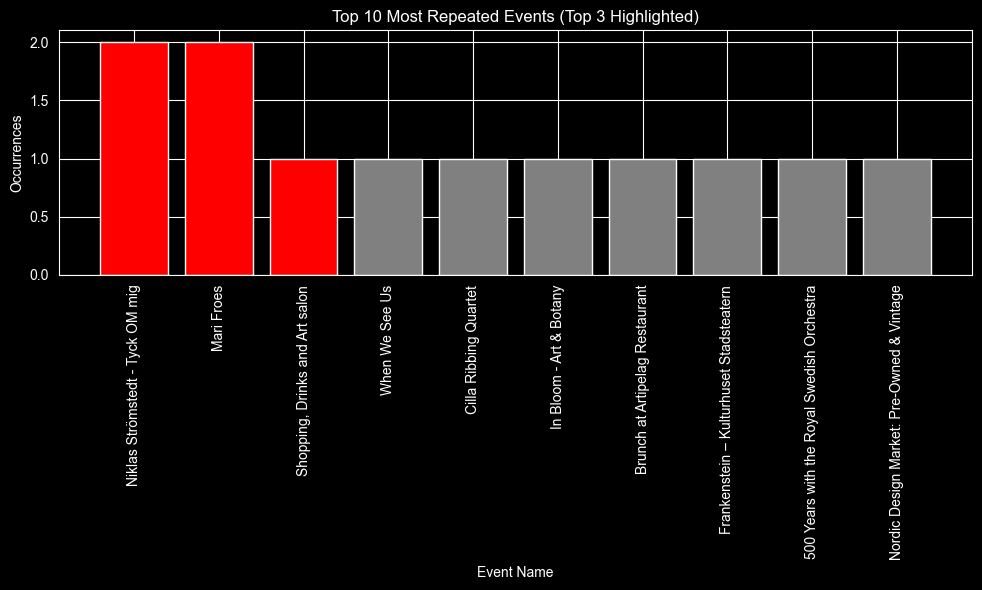

In [10]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data 
data = most_repeated_events.sort_values(by="occurrences", ascending=False)

# Top 3 events
top3 = data.head(3)["name"]

# Colors (highlight top 3)
colors = ["red" if name in top3.values else "grey"
          for name in data["name"]]

# Plot
ax.bar(data["name"], data["occurrences"], color=colors)

# Labels
ax.set_title("Top 10 Most Repeated Events (Top 3 Highlighted)")
ax.set_xlabel("Event Name")
ax.set_ylabel("Occurrences")
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## Top venues by event volume(Top 10)

In [11]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Debaser Strand,37
1,Debaser Nova,35
2,Avicii Arena,17
3,Fållan,14
4,NaN,14
5,Kollektivet Livet Bar och Scen,10
6,Gamla stan,10
7,Nalen,8
8,Ersta kyrka,7
9,Artipelag,7


## Visulization for top venues by venue

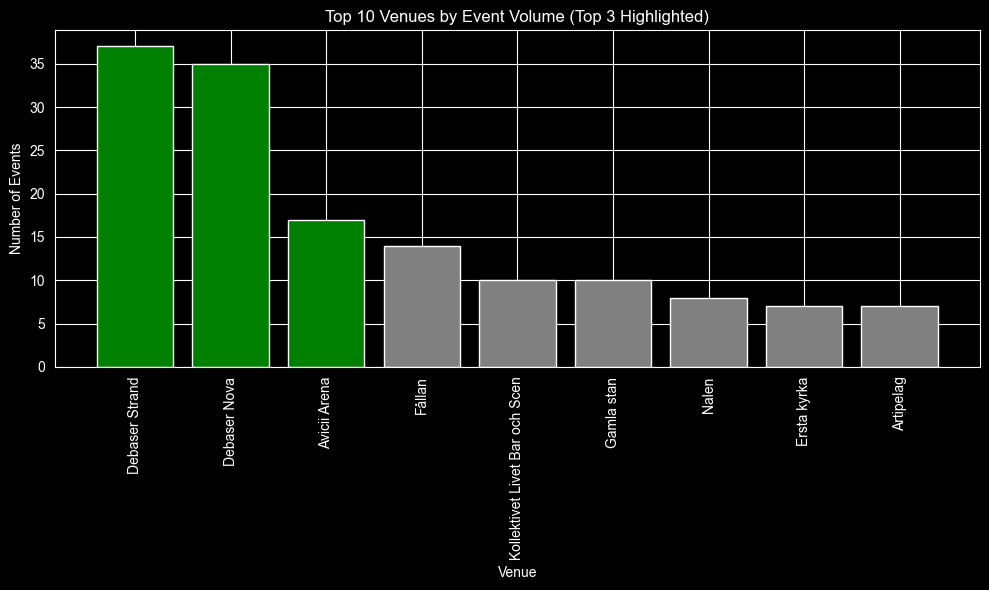

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data
data = top_venues_by_event_vol.sort_values(by="total_events", ascending=False)
data = top_venues_by_event_vol.dropna(subset=["venue_name"]).sort_values(by="total_events", ascending=False)
# Top 3 venues
top3 = data.head(3)["venue_name"]

# Colors (highlight top 3)
colors = ["green" if venue in top3.values else "grey"
          for venue in data["venue_name"]]

# Plot
ax.bar(data["venue_name"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 10 Venues by Event Volume (Top 3 Highlighted)")
ax.set_xlabel("Venue")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

## Events by day of week

In [13]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,118
1,Sunday,114
2,Friday,70
3,Wednesday,59
4,Thursday,42
5,Tuesday,39
6,Monday,38


## Events by month of the year 

In [14]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,270
1,June,63
2,September,32
3,October,31
4,November,26
5,August,25
6,July,21
7,December,4
8,February,4
9,April,3


## Segment - Genre breakdown

In [15]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Music,Jazz & Blues,208
1,Arts & Theatre,Culture & Arts,72
2,Arts & Theatre,Film,30
3,Miscellaneous,Food & Drink,29
4,Arts & Theatre,Guided Tours,25
5,Music,Culture & Arts,21
6,Sports,Games & Championships,19
7,Miscellaneous,Miscellaneous,17
8,Arts & Theatre,Miscellaneous,15
9,Music,Miscellaneous,13


## Peak hours oveerall 

In [16]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,NaN,480


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [17]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,PUMA HYROX World Championships Stockholm,Sports,Games & Championships
1,BAD BUNNY,Music,Miscellaneous
2,Sweden International Horse Show 2026,Miscellaneous,Conventions & Fairs
3,System Of A Down+Queens of the Stone Age,Music,Jazz & Blues
4,The Weeknd – After Hours Til Dawn Stadium Tour,Music,Jazz & Blues
5,Foo Fighters - TAKE COVER TOUR,Music,Jazz & Blues


## Top 5 Genre 

In [18]:
top_5_genres = con.execute("""
    SELECT genre, COUNT(*) AS total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    LIMIT 5;
""").df()


top_5_genres

,genre,total_events
0,Jazz & Blues,208
1,Culture & Arts,104
2,Miscellaneous,45
3,Food & Drink,32
4,Film,30


## Visualization for top genres 

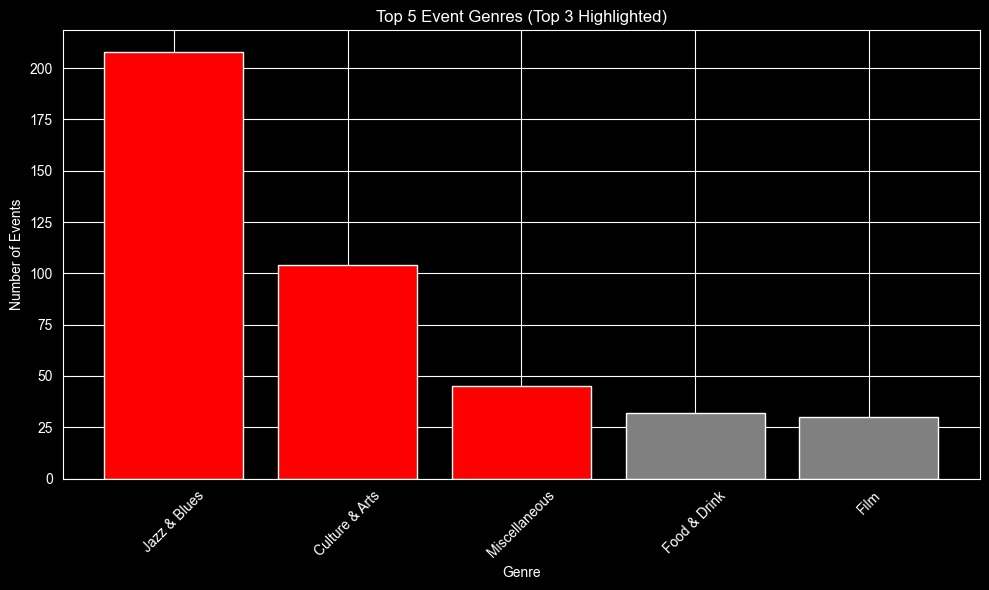

In [19]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data
data = top_5_genres.sort_values(by="total_events", ascending=False)

# Identify top 3
top3 = data.head(3)["genre"]

# Create colors
colors = ["red" if data in top3.values else "grey"
          for data in data["genre"]]

# Plot
ax.bar(data["genre"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 5 Event Genres (Top 3 Highlighted)")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## Total number of events per month for the year 2026

In [20]:
events_2026_monthly = con.execute("""
    SELECT 
        month_num,
        month_name,
        COUNT(*) AS total_events
    FROM events
    WHERE year = 2026
    GROUP BY month_num, month_name
    ORDER BY month_num;
""").df()

events_2026_monthly

,month_num,month_name,total_events
0,5,May,270
1,6,June,62
2,7,July,21
3,8,August,25
4,9,September,32
5,10,October,31
6,11,November,26
7,12,December,4


## Line chart for Visualization 

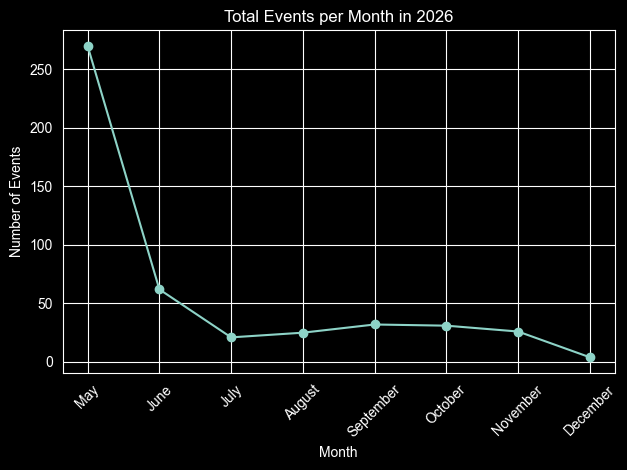

In [21]:


fig, ax = plt.subplots()

ax.plot(
    events_2026_monthly["month_name"],
    events_2026_monthly["total_events"],
    marker="o"
)

ax.set_title("Total Events per Month in 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EDA for Museum Activities in Stockholm

In [22]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("../data/output/stockholm_museums_complete.csv")

df.head()


,event_id,name,url,venue_name,venue_address,venue_city,venue_lat,venue_lon,rating,num_reviews,...,year,month_name,is_free,popularity_score,popularity_index,adult_price_sek,child_price_sek,free_age_range,student_price_sek,senior_price_sek
0,ChIJrymDbVSdX0YRQTLBtPGa8M8,Vasamuseet,https://www.vasamuseet.se/,Vasamuseet,"Galärvarvsvägen 14, 115 21 Stockholm, Sverige",Stockholm,59.328023,18.091396,4.8,66926,...,2026,All Year,False,1241.8,100.0,240.0,0.0,0–18,NaN,NaN
1,ChIJN5Ta_qqCX0YRMYVG1s-2NSw,Skansen,https://www.skansen.se/,Skansen,"Djurgårdsslätten 49-51, 115 21 Stockholm, Sverige",Stockholm,59.326323,18.105858,4.5,34496,...,2026,All Year,False,835.8,62.9,329.0,120.0,0–15,279.0,279.0
2,ChIJBf9B06qCX0YRR46XNXjwFUo,ABBA The Museum,https://www.abbathemuseum.com/,ABBA The Museum,"Djurgårdsvägen 68, 115 21 Stockholm, Sverige",Stockholm,59.325091,18.096781,4.5,20093,...,2026,All Year,False,637.9,44.8,329.0,120.0,0–6,279.0,279.0
3,ChIJhaN0M_l3X0YRpOq8uRb_RcA,Fotografiska Stockholm,https://stockholm.fotografiska.com/,Fotografiska Stockholm,"Stadsgårdshamnen 22, 116 45 Stockholm, Sverige",Stockholm,59.317962,18.084827,4.4,19504,...,2026,All Year,False,614.5,42.6,NaN,NaN,NaN,NaN,NaN
4,ChIJxagZg1OdX0YRGKnPhRyci9c,Nordiska museet,https://www.nordiskamuseet.se/,Nordiska museet,"Djurgårdsvägen 6-16, 115 93 Stockholm, Sverige",Stockholm,59.329008,18.094268,4.3,11098,...,2026,All Year,False,453.0,27.9,160.0,0.0,3–18,130.0,130.0


In [23]:
df.describe()

,venue_lat,venue_lon,rating,num_reviews,price_level,year,popularity_score,popularity_index,adult_price_sek,child_price_sek,student_price_sek,senior_price_sek
count,20.000000,20.000000,20.000000,20.000000,0.0,20.0,20.000000,20.000000,18.000000,18.000000,10.000000,11.000000
mean,59.331897,18.082953,4.445000,11320.800000,NaN,2026.0,408.575000,23.825000,186.111111,45.500000,162.700000,167.454545
std,0.011870,0.015764,0.176143,15422.255906,NaN,0.0,264.043774,24.142186,74.303740,68.670783,72.226573,67.997594
min,59.317962,18.053878,4.100000,1131.000000,NaN,2026.0,148.000000,0.000000,0.000000,0.000000,75.000000,75.000000
25%,59.326254,18.070844,4.300000,2706.750000,NaN,2026.0,227.425000,7.250000,160.000000,0.000000,116.250000,125.000000
50%,59.328773,18.083012,4.450000,7238.500000,NaN,2026.0,370.450000,20.350000,165.000000,0.000000,140.000000,150.000000
75%,59.333457,18.092389,4.500000,9715.750000,NaN,2026.0,428.625000,25.650000,229.000000,113.750000,200.500000,202.000000
max,59.368975,18.118803,4.800000,66926.000000,NaN,2026.0,1241.800000,100.000000,329.000000,195.000000,279.000000,279.000000


In [24]:
df.shape

(20, 26)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event_id           20 non-null     str    
 1   name               20 non-null     str    
 2   url                20 non-null     str    
 3   venue_name         20 non-null     str    
 4   venue_address      20 non-null     str    
 5   venue_city         20 non-null     str    
 6   venue_lat          20 non-null     float64
 7   venue_lon          20 non-null     float64
 8   rating             20 non-null     float64
 9   num_reviews        20 non-null     int64  
 10  price_level        0 non-null      float64
 11  opening_hours      20 non-null     str    
 12  status             20 non-null     str    
 13  segment            20 non-null     str    
 14  genre              20 non-null     str    
 15  subgenre           20 non-null     str    
 16  year               20 non-null     int6

In [26]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Top Attractions by Popularity

In [27]:
top_attractions = con.execute("""
    SELECT name, popularity_score
    FROM events
    ORDER BY popularity_score DESC
    LIMIT 5
""").df()

top_attractions

,name,popularity_score
0,Vasamuseet,1241.8
1,Skansen,835.8
2,ABBA The Museum,637.9
3,Fotografiska Stockholm,614.5
4,Nordiska museet,453.0


In [28]:
# Color definitons 

GRAY_1 = "#EAEAEA"
GRAY_2 = "#B0BEC5"
GRAY_3 = "#37474F"


BLUE = "#1E88E5"
GREEN = "#43A047"
RED = "#E53935"
ORANGE = "#FB8C00"
PURPLE = "#8E24AA"

## Visualization graph for top attractions by popularity 

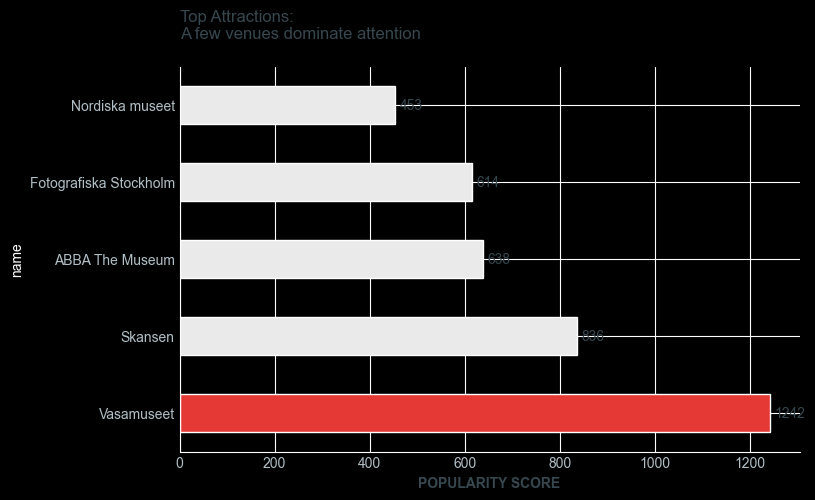

In [29]:
df_plot = top_attractions.sort_values("popularity_score")

colors = [GRAY_1]*len(df_plot)
colors[-1] = RED   

ax = df_plot.plot(
    kind="barh",
    x="name",
    y="popularity_score",
    figsize=(8,5),
    color=colors,
    legend=False
)

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis="both", colors=GRAY_2, length=0)

ax.set_xlabel("POPULARITY SCORE", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Top Attractions:\nA few venues dominate attention",
    loc="left",
    color=GRAY_3,
    pad=20
)

# labels
for i, v in enumerate(df_plot["popularity_score"]):
    ax.text(v + 10, i, f"{v:.0f}", va="center", color=GRAY_3)

ax.invert_yaxis()

## Free vs Paid Distribution 

In [30]:
free_vs_paid = con.execute("""
    SELECT is_free, COUNT(*) as total
    FROM events
    GROUP BY is_free
""").df()

free_vs_paid

,is_free,total
0,False,13
1,True,7


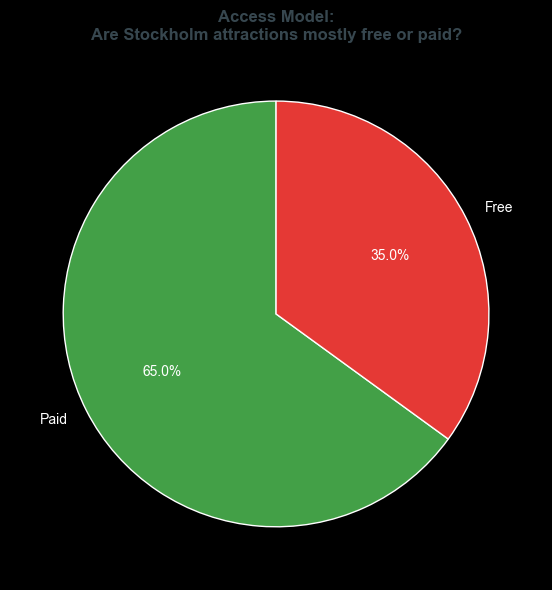

In [31]:
labels = ["Paid", "Free"] if False in free_vs_paid["is_free"].values else free_vs_paid["is_free"]

colors = [GREEN if val == False else RED for val in free_vs_paid["is_free"]]

fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    free_vs_paid["total"],
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

ax.set_title(
    "Access Model:\nAre Stockholm attractions mostly free or paid?",
    color=GRAY_3,
    fontweight="bold"
)

plt.tight_layout()

## Top 5 Reviews (Social Power)

In [32]:
top_reviews = con.execute("""
    SELECT name, num_reviews
    FROM events
    ORDER BY num_reviews DESC
    LIMIT 5
""").df()

top_reviews

,name,num_reviews
0,Vasamuseet,66926
1,Skansen,34496
2,ABBA The Museum,20093
3,Fotografiska Stockholm,19504
4,Nordiska museet,11098


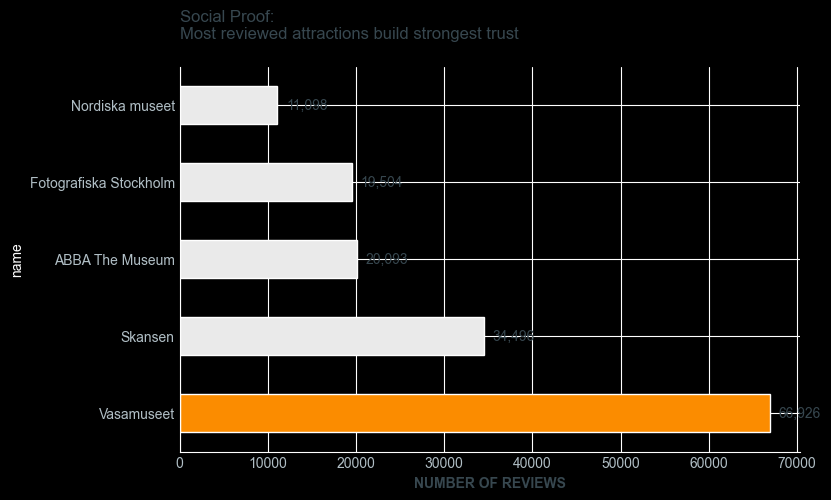

In [33]:
df_plot = top_reviews.sort_values("num_reviews")

colors = [GRAY_1]*len(df_plot)
colors[-1] = ORANGE   # highlight most reviewed

ax = df_plot.plot(
    kind="barh",
    x="name",
    y="num_reviews",
    figsize=(8,5),
    color=colors,
    legend=False
)

ax.spines[["top","right"]].set_visible(False)
ax.tick_params(axis="both", colors=GRAY_2, length=0)

ax.set_xlabel("NUMBER OF REVIEWS", color=GRAY_3, fontweight="bold")

ax.set_title(
    "Social Proof:\nMost reviewed attractions build strongest trust",
    loc="left",
    color=GRAY_3,
    pad=20
)

# labels
for i, v in enumerate(df_plot["num_reviews"]):
    ax.text(v + 1000, i, f"{int(v):,}", va="center", color=GRAY_3)

ax.invert_yaxis()